<a href="https://colab.research.google.com/github/RajShekhar0341/DataScience/blob/main/CNN%2CApriori%2CEvaluation%26Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Phase 1: Data Preprocessing and Feature Engineering

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Upload the file from local system
from google.colab import files
uploaded = files.upload()

df.head()


Saving Global_Pollution_Analysis.csv to Global_Pollution_Analysis (1).csv


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [ ]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Fill numeric missing values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)


Missing values:
 Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64


In [ ]:
# Normalize pollution columns
scaler = MinMaxScaler()
pollution_cols = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
df[pollution_cols] = scaler.fit_transform(df[pollution_cols])


In [ ]:
le_country = LabelEncoder()
le_year = LabelEncoder()

df['Country_Encoded'] = le_country.fit_transform(df['Country'])
df['Year_Encoded'] = le_year.fit_transform(df['Year'])


In [ ]:
df['Energy_Consumption (in MWh)'] = df['Energy_Consumption_Per_Capita (in MWh)'] * df['Population (in millions)']


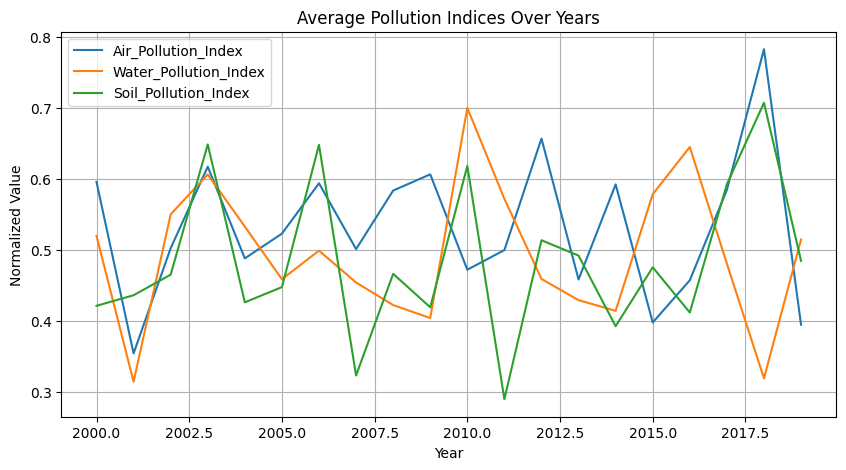

In [ ]:
pollution_trend = df.groupby('Year')[pollution_cols].mean().reset_index()

# Plot pollution trends
plt.figure(figsize=(10, 5))
for col in pollution_cols:
    sns.lineplot(data=pollution_trend, x='Year', y=col, label=col)
plt.title("Average Pollution Indices Over Years")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Thresholds by quantiles
air_thresh = df['Air_Pollution_Index'].quantile([0.33, 0.66]).values
water_thresh = df['Water_Pollution_Index'].quantile([0.33, 0.66]).values

def get_category(value, thresholds):
    if value <= thresholds[0]:
        return 'Low'
    elif value <= thresholds[1]:
        return 'Medium'
    else:
        return 'High'

df['Air_Pollution_Level'] = df['Air_Pollution_Index'].apply(lambda x: get_category(x, air_thresh))
df['Water_Pollution_Level'] = df['Water_Pollution_Index'].apply(lambda x: get_category(x, water_thresh))


In [ ]:
df.head()


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Country_Encoded,Year_Encoded,Energy_Consumption (in MWh),Air_Pollution_Level,Water_Pollution_Level
0,Hungary,2005,0.898042,0.553778,0.295481,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,77,5,530.2832,High,Medium
1,Singapore,2001,0.147062,0.173673,0.768178,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,147,1,717.8175,Low,Low
2,Romania,2016,0.166727,0.310542,0.800768,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,136,16,1636.7805,Low,Low
3,Cook Islands,2018,0.929982,0.214222,0.596973,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,38,18,52.8840,High,Low
4,Djibouti,2008,0.520331,0.573161,0.799537,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,46,8,2394.9168,Medium,Medium


#Phase 2 (Apriori Algorithm)

In [ ]:
!pip install mlxtend


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder


In [ ]:
#Convert numerical columns to categorical bins
df['Energy_Recovered_Level'] = pd.cut(df['Energy_Recovered (in GWh)'],
                                      bins=3, labels=["Low", "Medium", "High"])

df['Renewable_Energy_Level'] = pd.cut(df['Renewable_Energy (%)'],
                                      bins=3, labels=["Low", "Medium", "High"])

# Step 3.2: Select categorical columns for association analysis
basket_df = df[['Air_Pollution_Level', 'Water_Pollution_Level',
                'Energy_Recovered_Level', 'Renewable_Energy_Level']]

# Step 3.3: Transform into list of transactions
transactions = basket_df.apply(lambda x: [f"{col}={val}" for col, val in zip(basket_df.columns, x)], axis=1).tolist()

# Encode for Apriori
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_apriori = pd.DataFrame(te_ary, columns=te.columns_)
df_apriori.head()


,Air_Pollution_Level=High,Air_Pollution_Level=Low,Air_Pollution_Level=Medium,Energy_Recovered_Level=High,Energy_Recovered_Level=Low,Energy_Recovered_Level=Medium,Renewable_Energy_Level=High,Renewable_Energy_Level=Low,Renewable_Energy_Level=Medium,Water_Pollution_Level=High,Water_Pollution_Level=Low,Water_Pollution_Level=Medium
0,True,False,False,False,True,False,True,False,False,False,False,True
1,False,True,False,True,False,False,True,False,False,False,True,False
2,False,True,False,True,False,False,False,True,False,False,True,False
3,True,False,False,False,True,False,False,True,False,False,True,False
4,False,False,True,False,True,False,False,False,True,False,False,True


In [ ]:
#Find frequent itemsets
frequent_itemsets = apriori(df_apriori, min_support=0.1, use_colnames=True)

#Extract association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

#Sort by lift
rules = rules.sort_values(by='lift', ascending=False)
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()


,antecedents,consequents,support,confidence,lift


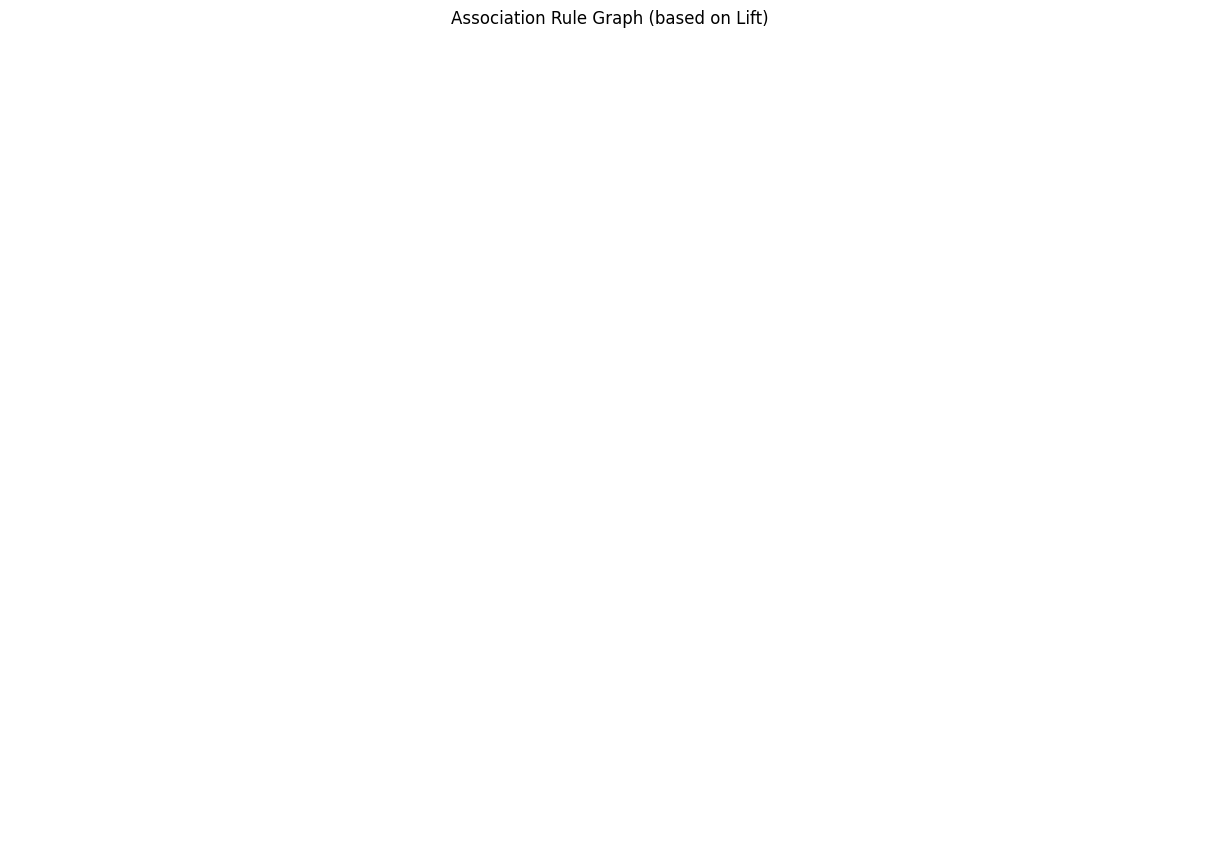

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph from association rules
G = nx.DiGraph()

for _, row in rules.iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c, weight=row['lift'])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5)
edges = G.edges(data=True)
weights = [d['weight'] for (_, _, d) in edges]

nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=3000, font_size=10, width=weights)
plt.title('Association Rule Graph (based on Lift)')
plt.show()


#Phase 3 – Evaluation & Validation of Apriori Rules

In [ ]:
# Display top 10 rules based on lift
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)


,antecedents,consequents,support,confidence,lift


In [ ]:
# Rule Evaluation Summary
print("Total rules generated:", len(rules))

# Rule strength thresholds
strong_rules = rules[(rules['confidence'] >= 0.7) & (rules['lift'] >= 1.2)]
print("Strong rules count (conf >= 0.7 & lift >= 1.2):", len(strong_rules))

# Show strong rules
strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(by='lift', ascending=False).head()


Total rules generated: 0
Strong rules count (conf >= 0.7 & lift >= 1.2): 0


,antecedents,consequents,support,confidence,lift


In [ ]:
from sklearn.model_selection import train_test_split

# Split basket data
train_data, test_data = train_test_split(transactions, test_size=0.3, random_state=42)

# Encode training data
te = TransactionEncoder()
train_encoded = te.fit(train_data).transform(train_data)
train_df = pd.DataFrame(train_encoded, columns=te.columns_)

# Apply Apriori on training set
train_itemsets = apriori(train_df, min_support=0.1, use_colnames=True)
train_rules = association_rules(train_itemsets, metric="confidence", min_threshold=0.6)
train_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()


,antecedents,consequents,support,confidence,lift


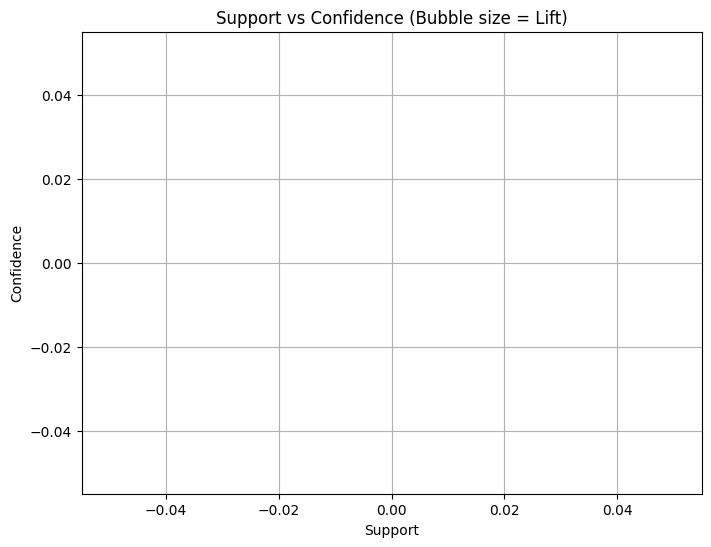

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='support', y='confidence', size='lift', data=rules)
plt.title('Support vs Confidence (Bubble size = Lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(True)
plt.show()
